In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

FigureTitle="Figure"

np.random.seed(1)
if not os.path.exists(FigureTitle):

   # Create a new directory because it does not exist
   os.makedirs(FigureTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

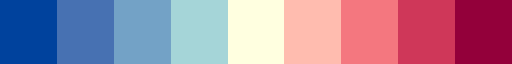

In [3]:
my_cmap

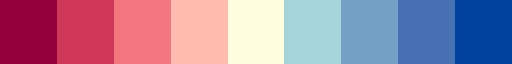

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
def pHcriteria(pH_list,return_type="Num"):
    pH_list=np.array(pH_list)
    O=1*(pH_list>6)+1*(pH_list>8)
    if return_type=="Num":
        return O
    if return_type=="Word":
        word_list=['acidic','neutral','alkalic']
        return [word_list[x] for x in O]
    if return_type=="Color":
        word_list=['r','g','b']
        return [word_list[x] for x in O]

def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix   

def EstimateErrorLassoRegression(IDX_list, x, y, order, alpha, beta, preprocess='Basic', verbose=False):
    communityIDX_list=np.unique(getCommunities(Communities_data,IDX_list)['CommunityIDX'])
    train_mse_list=[]
    test_mse_list=[]
    
    if preprocess=='Basic':
        y_tofit=y.copy()
    elif preprocess=='Normalize':
        y_tofit=(y.copy()-0.5)*2
    elif preprocess=='Tan':
        y_tofit=np.tan((y.copy()-0.5)*np.pi/2)
        
    for communityID_toTest in communityIDX_list:  
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']!=communityID_toTest)[0]
        test_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']==communityID_toTest)[0]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        # Predict the target values for the test set
        y_pred_train = model.predict(X_train_poly)
        y_pred_test = model.predict(X_test_poly)

        # Evaluate the model
        train_mse = np.mean((y_train-y_pred_train)**2)
        test_mse = np.mean((y_test-y_pred_test)**2)
        ref_mse= np.var(y_tofit)
        if verbose:
            print(f'Mean Train Squared Error: {train_mse}')
            print(f'Mean Test Squared Error: {test_mse, y_test, y_pred_test}')
        plt.scatter(y_test,y_pred_test)
        train_mse_list.append(train_mse/ref_mse)
        test_mse_list.append(test_mse/ref_mse)
    return communityIDX_list, train_mse_list, test_mse_list
    

########################################################
########################################################
# Fig 1-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
IDX_list=np.sort(Community_PermutateList("F", "S", "M", "C", 12, 1))
IDX_list[10]

'P5-25'

########################################################
########################################################
# Fig 1-2
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

########################################################
########################################################
# Fig 1-3
########################################################
########################################################


In [8]:
sns.color_palette("Set2",10)

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

########################################################
########################################################
# Fig 1-4
########################################################
########################################################

## This figure is cartoon
## I am going to use C2+C8 : 8-27

(array([2.23140496, 1.48760331, 1.48760331, 1.73553719, 1.40495868,
        1.57024793, 0.99173554, 1.15702479, 1.32231405, 1.07438017,
        0.82644628, 0.74380165, 0.74380165, 0.66115702, 0.16528926,
        0.5785124 , 0.49586777, 0.16528926, 0.5785124 , 0.5785124 ]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

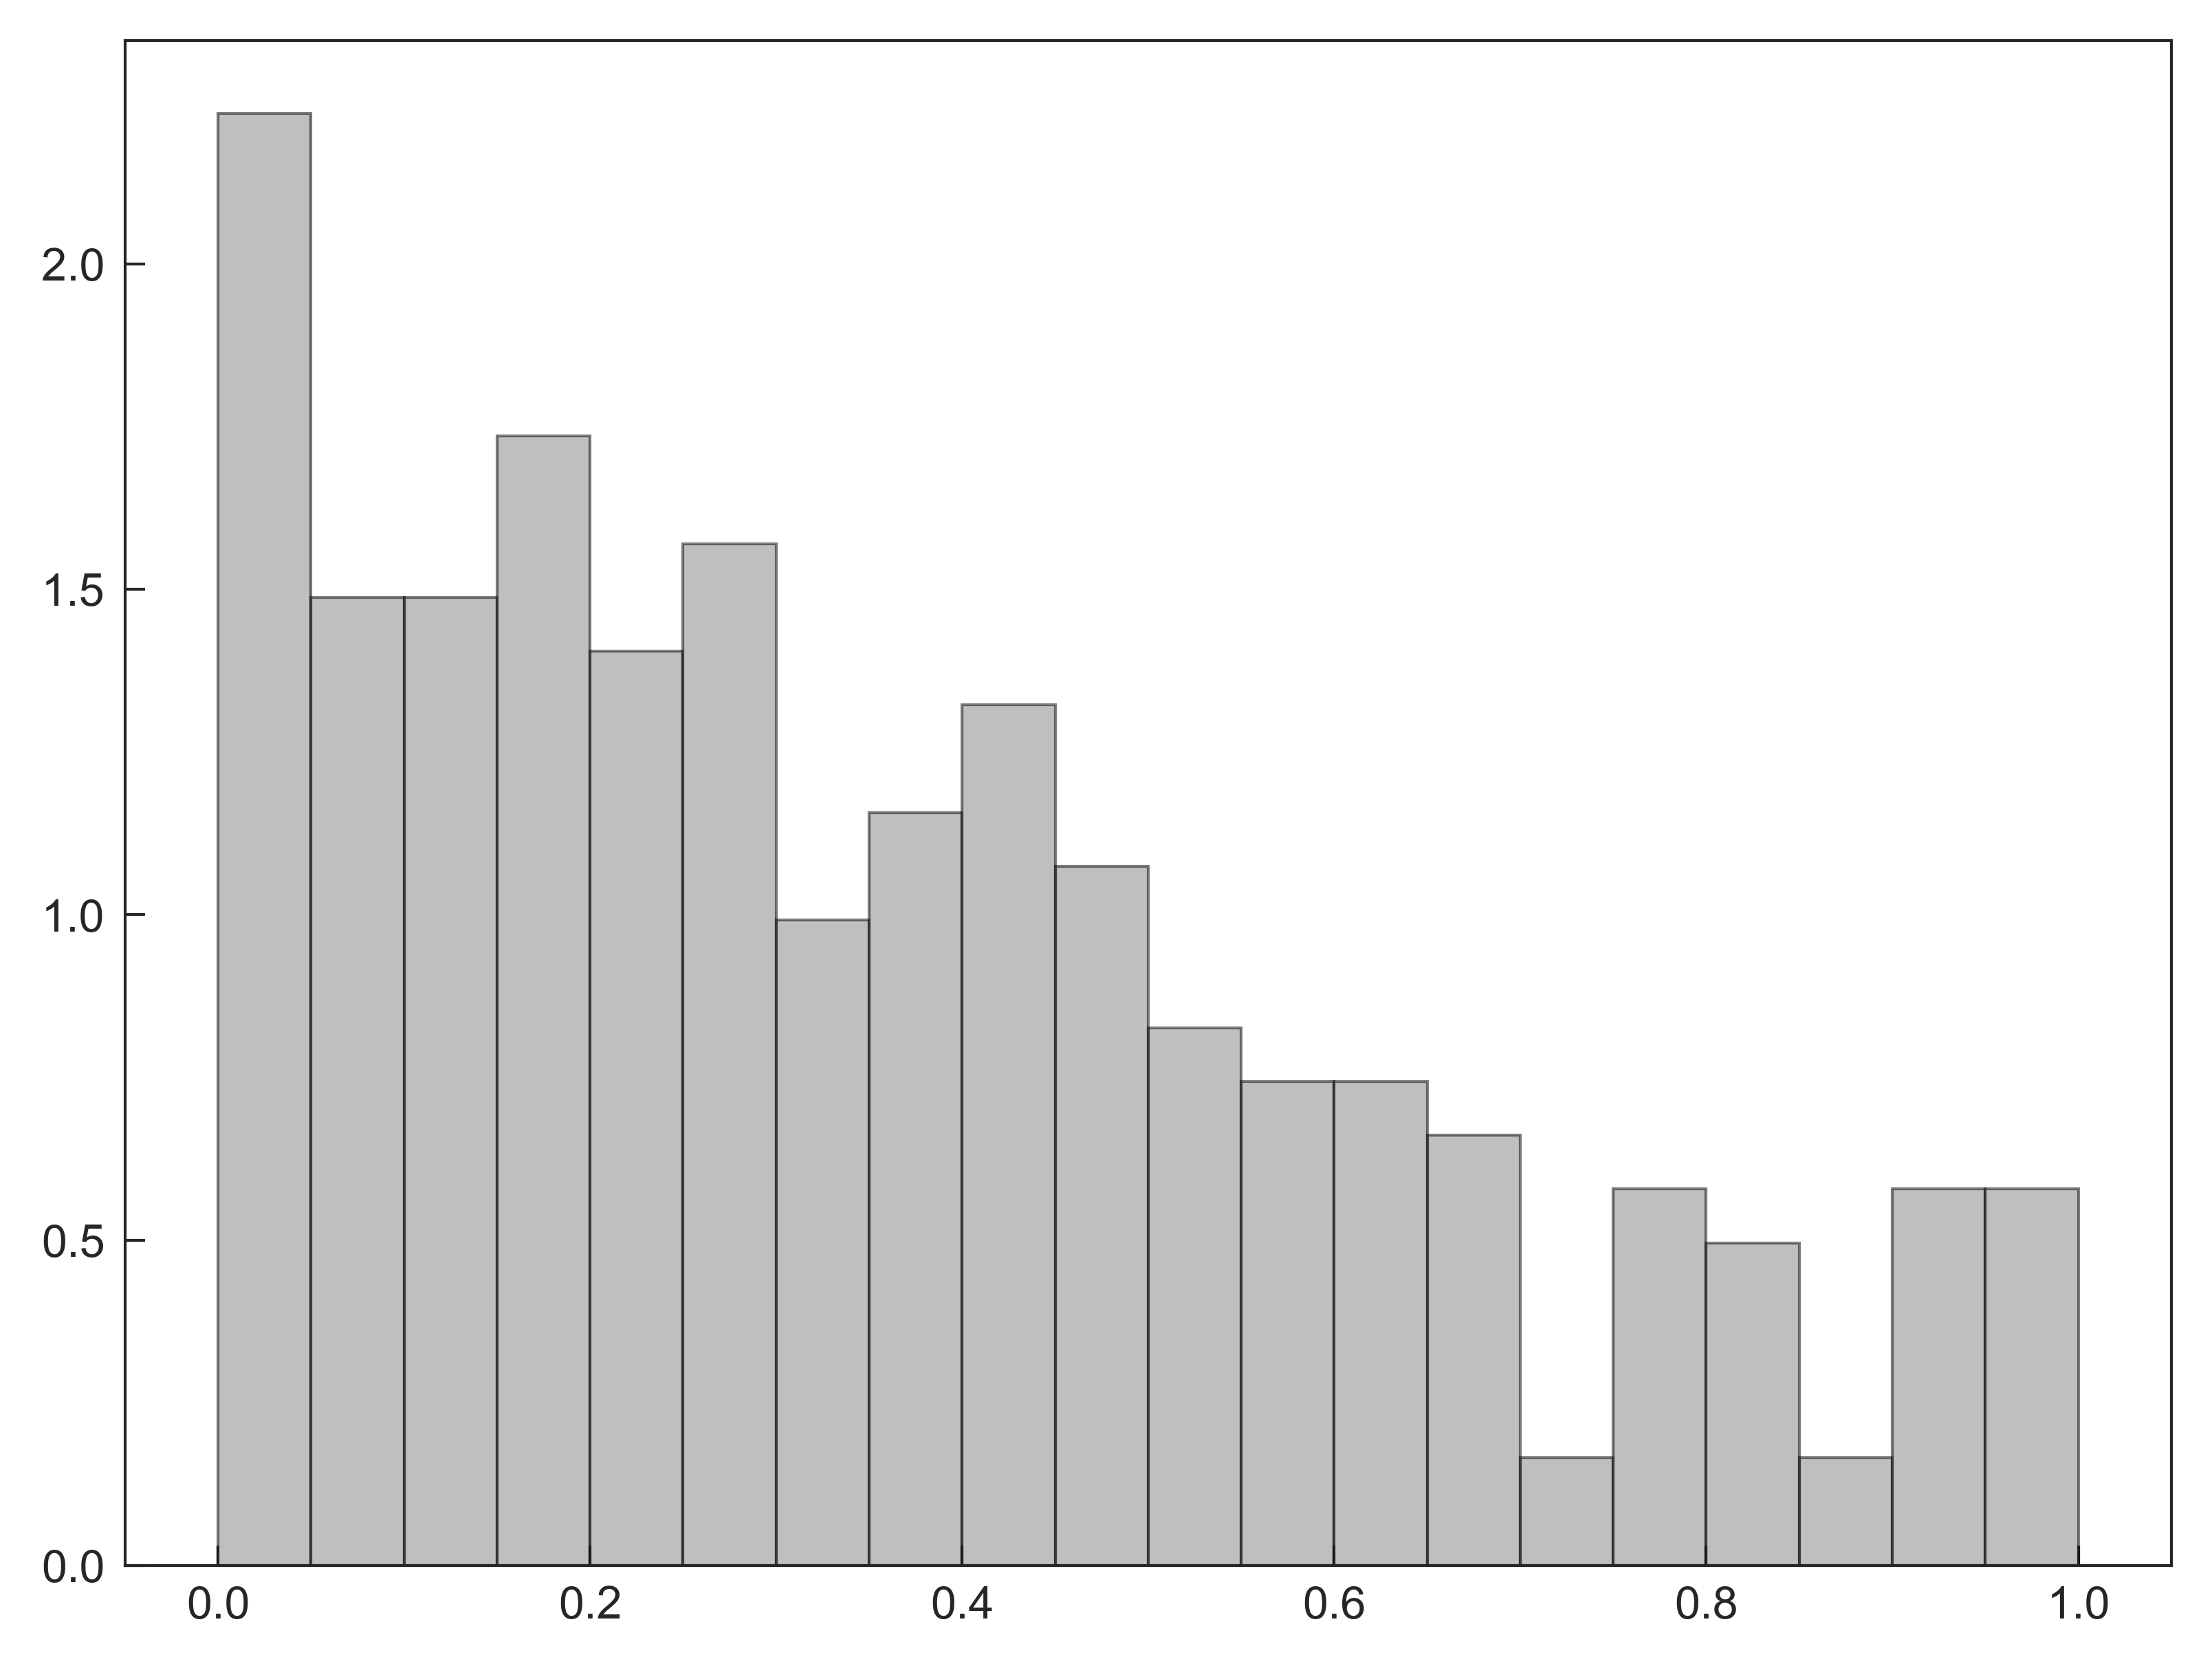

In [9]:
IDX_list=np.sort(Community_PermutateList("F", "S", "M", "C", 12, -1))
idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])

degList=np.zeros(43)
species_num=len(degList)
data_null_model=[]
for i in range(len(idx)):
    for _ in range(10):
        A=np.random.rand(species_num)<0.5
        c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
        c_1=Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:]
        c_2=Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:]

        mix_label=(np.random.rand(species_num)<0.5).astype(int)
        moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
        moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
        moc_c1=moc_c1/np.sum(moc_c1)
        moc_c2=moc_c2/np.sum(moc_c2)

        F1=np.sum(np.minimum(moc_c1,c_mix))
        F2=np.sum(np.minimum(moc_c2,c_mix))

        similarity=(F1)/(F1+F2)
        data_null_model.append(2*similarity-1)


plt.hist(data_null_model, bins=np.arange(0,1.05,0.05), density=True, alpha=0.5, color='grey',label="Fraction", edgecolor='black', linewidth=0.5)


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_91986/1240807675.py:172: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, shade=True,bw_adjust=.5, color=my_cmap(0))
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_91986/1240807675.py:227: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_null_model, shade=True,bw_adjust=.5, color='grey')


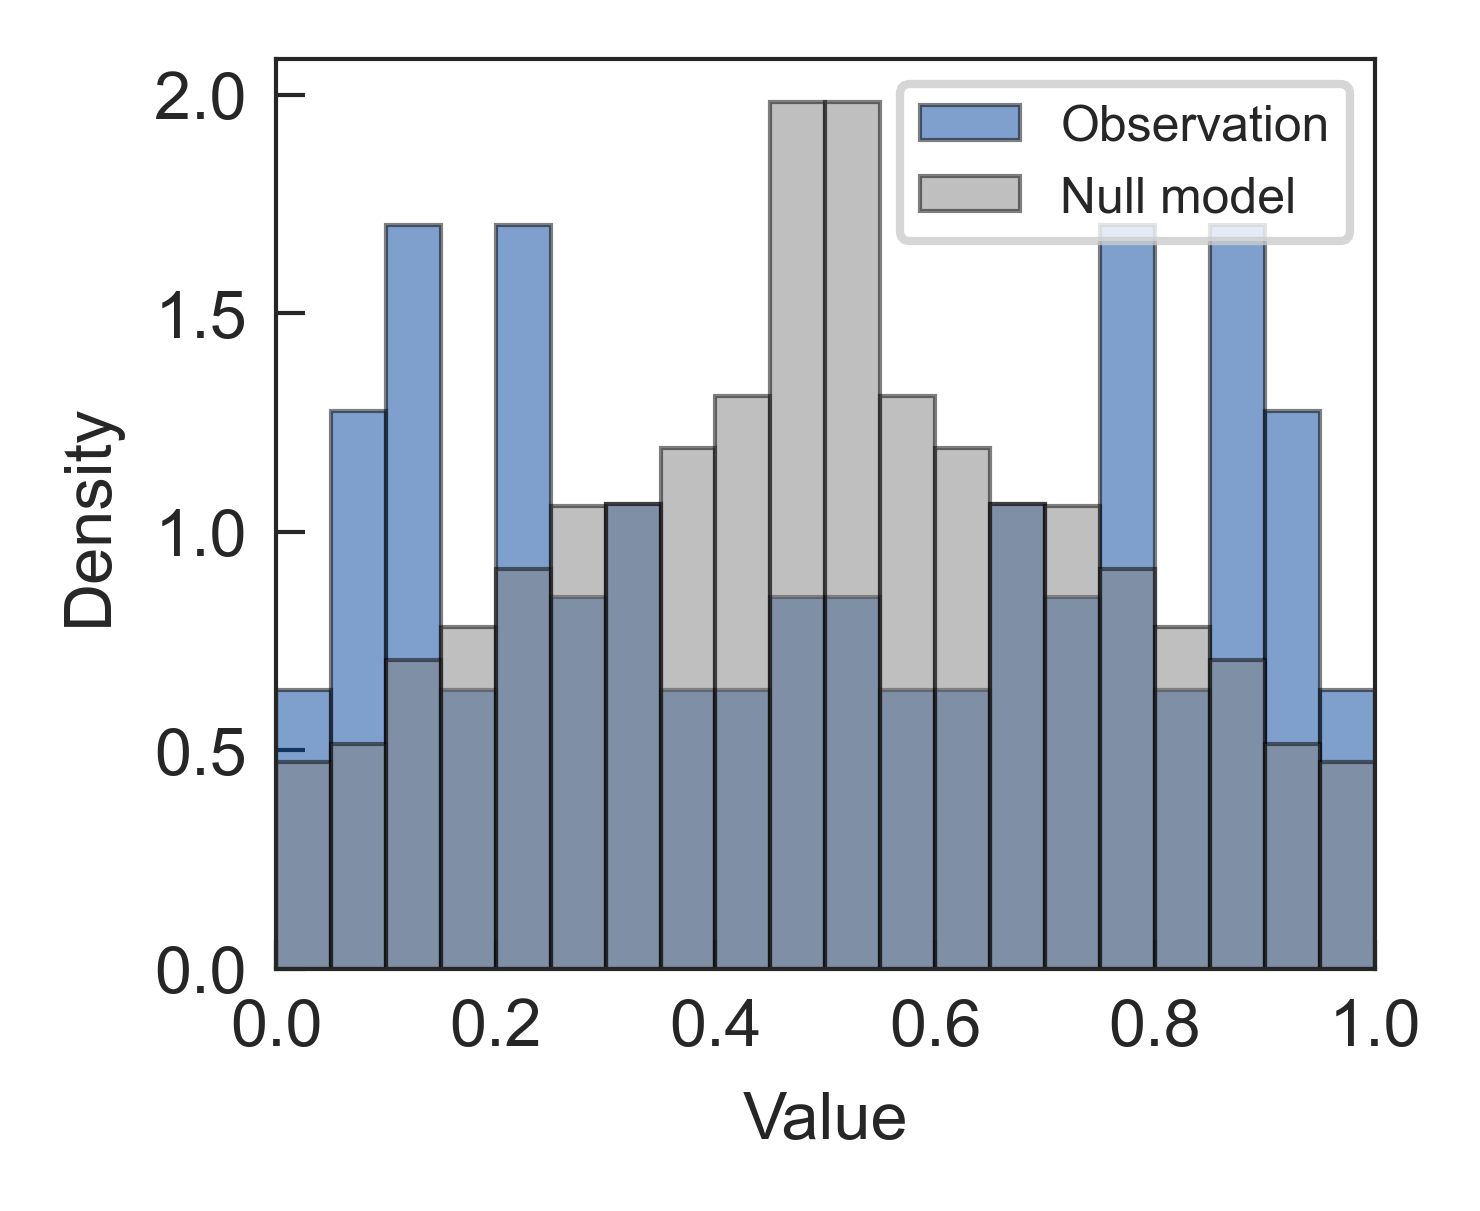

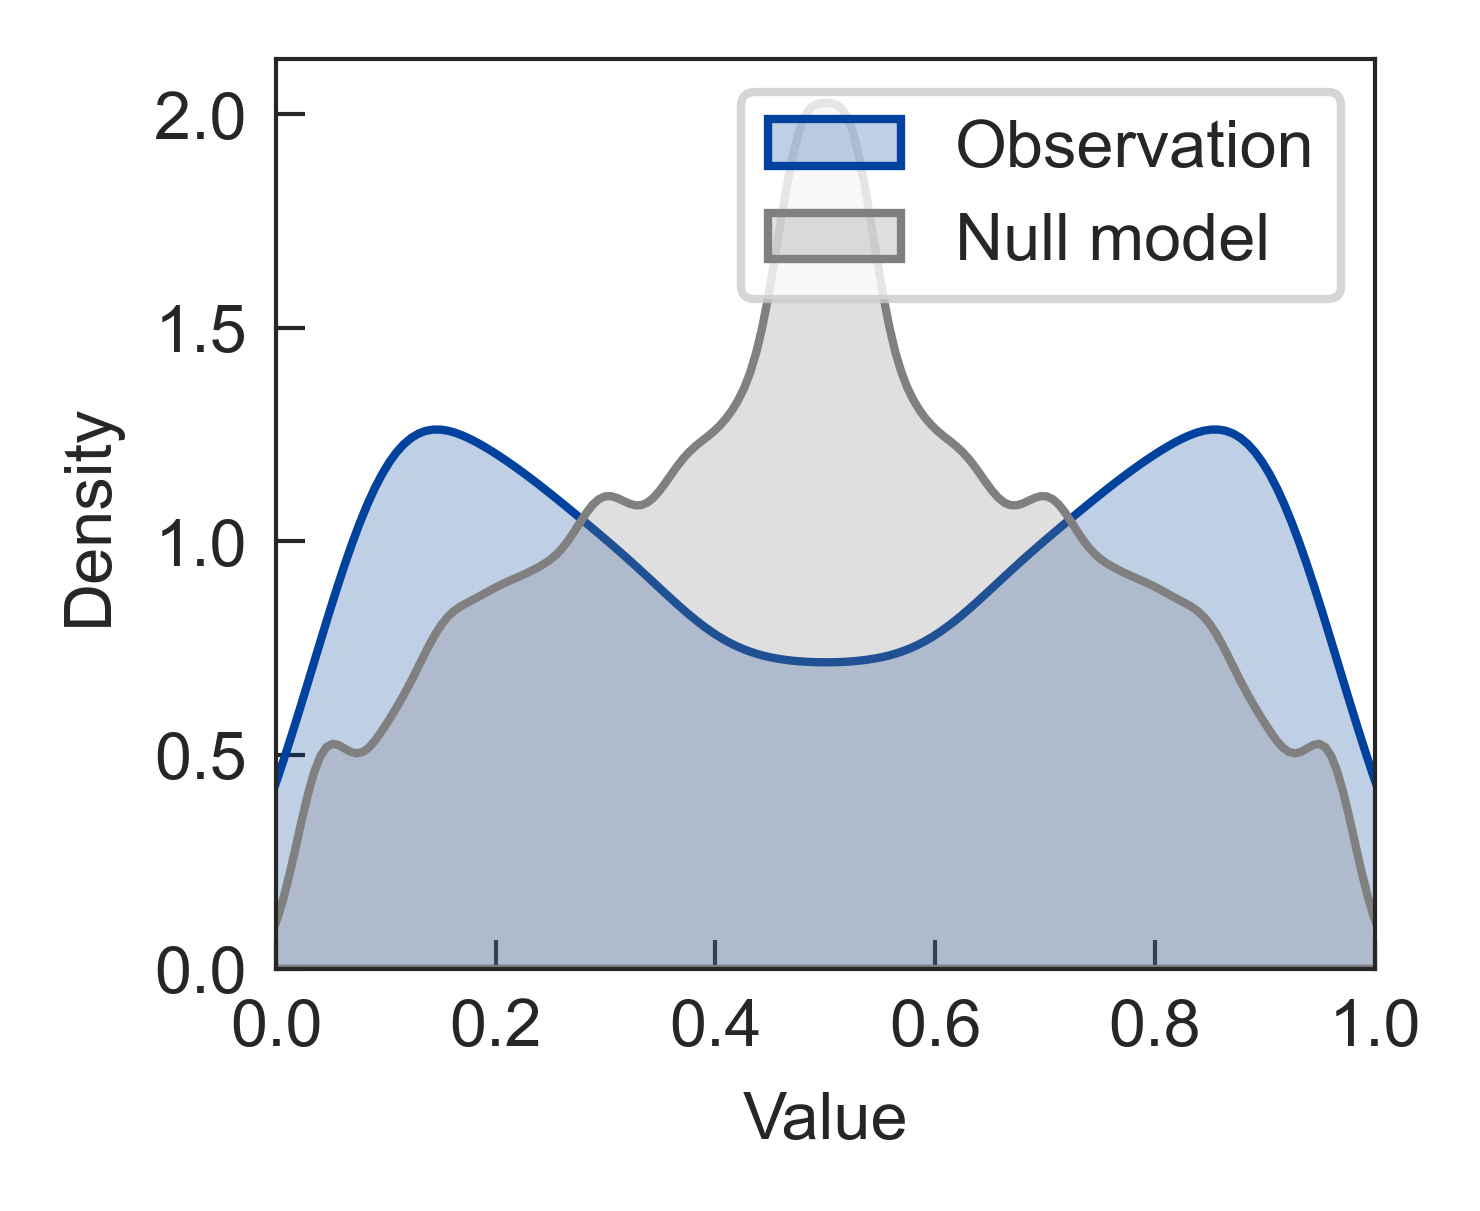

In [10]:
########################################################
########################################################
# Fig 1-5-1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data

f, ax = plt.subplots(1, figsize=(60*mm,50*mm), facecolor='w', edgecolor='k')
if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data[Variable2plot]
    data = np.concatenate((data,1-data))


    # Compute the histogram data without plotting
    hist_data, bin_edges = np.histogram(data, bins=15, density=True)

    # Plot the histogram with shaded area

    # For each data point, find which bin it belongs to and then float it slightly above that bin
    y_positions = []
    for d in data:
        #bin_idx = np.digitize(d, bin_edges) - 1
        #y_positions.append(0.5+0.14*np.random.rand())
        bin_idx = np.digitize(d, bin_edges) - 2
        y_positions.append(hist_data[bin_idx]*np.random.rand()*0.7)

    # Add some offset so that points float above the histogram bars
    y_offset = max(hist_data) * 0.02
    y_positions = [y + y_offset for y in y_positions]

    #plt.scatter(data, y_positions, marker='o', color='r', s=10, alpha=0.5, label="Data Points")
    plt.hist(data, bins=np.arange(0,1.05,0.05), density=True, alpha=0.5, color=my_cmap(0), label="Fraction", edgecolor='black', linewidth=0.5)

    #sns.kdeplot(data, shade=True,bw_adjust=.6)

if True:
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(50):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(similarity)
            data_null_model.append(1-similarity)
    plt.hist(data_null_model, bins=np.arange(0,1.05,0.05), density=True, alpha=0.5, color='grey',label="Fraction", edgecolor='black', linewidth=0.5)
    
    
#plt.title("KDE with Floating Data Points")
plt.legend(['Observation', 'Null model'],prop={'size': 6})
plt.xlabel("Value")
plt.ylabel("Density")
plt.xlim(0, 1)

f.savefig(FigureTitle + '/Fig_1-5_DistributionOfSimilarity_versionHisto.svg', bbox_inches='tight')


f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')
if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data =  getCoalescence(Coalescence_data,IDX_list)
    data =  data[Variable2plot]
    data = np.concatenate((data,1-data))


    # Compute the histogram data without plotting
    hist_data, bin_edges = np.histogram(data, bins=15, density=True)

    # Plot the histogram with shaded area
    

    # For each data point, find which bin it belongs to and then float it slightly above that bin
    y_positions = []
    for d in data:
        #bin_idx = np.digitize(d, bin_edges) - 1
        #y_positions.append(0.5+0.14*np.random.rand())
        bin_idx = np.digitize(d, bin_edges) - 2
        y_positions.append(hist_data[bin_idx]*np.random.rand()*0.7)
    
    # Add some offset so that points float above the histogram bars
    y_offset = max(hist_data) * 0.02
    y_positions = [y + y_offset for y in y_positions]

    #plt.hist(data, bins=20, density=True, alpha=0.7, label="Fraction")
    #plt.scatter(data, y_positions, marker='o', color='r', s=10, alpha=0.5, label="Data Points")
    sns.kdeplot(data, shade=True,bw_adjust=.5, color=my_cmap(0))

#if False:
#    data_null_model=[]
# Null model
#    p_null = 0.5
#    for _ in range(500): 
#        c1=np.random.rand(12)
#        c1=c1/np.sum(c1)
#        c2=np.random.rand(12)
#        c2=c2/np.sum(c2)
#        survive=np.random.rand(24)<p_null
#        cm=survive*np.random.rand(24)
#        cm=cm/np.sum(cm)
#        similarity=np.sum(np.minimum(c1,cm[0:12]))/(np.sum(np.minimum(c1,cm[0:12]))+np.sum(np.minimum(c2,cm[12:24])))
#        data_null_model.append(similarity)
#        data_null_model.append(1-similarity)

#    data_null_model = np.array(data_null_model)
#    sns.kdeplot(data_null_model, shade=True,color='grey',bw_adjust=1, linewidth=1.0)
#    #plt.hist(data_null_model, bins=20, density=True, alpha=0.7, label="Fraction")
    
if True:
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(50):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(similarity)
            data_null_model.append(1-similarity)

    sns.kdeplot(data_null_model, shade=True,bw_adjust=.5, color='grey')


#plt.title("KDE with Floating Data Points")
plt.legend(['Observation', 'Null model'])
plt.xlabel("Value")
plt.ylabel("Density")
plt.xlim(0, 1)


f.savefig(FigureTitle + '/Fig_1-5_DistributionOfSimilarity_versionKDE.svg', bbox_inches='tight')


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_91986/2284532333.py:172: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, shade=True,bw_adjust=1, color=my_cmap(0))
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_91986/2284532333.py:207: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_null_model, shade=True,color='grey',bw_adjust=1, linewidth=1.0)


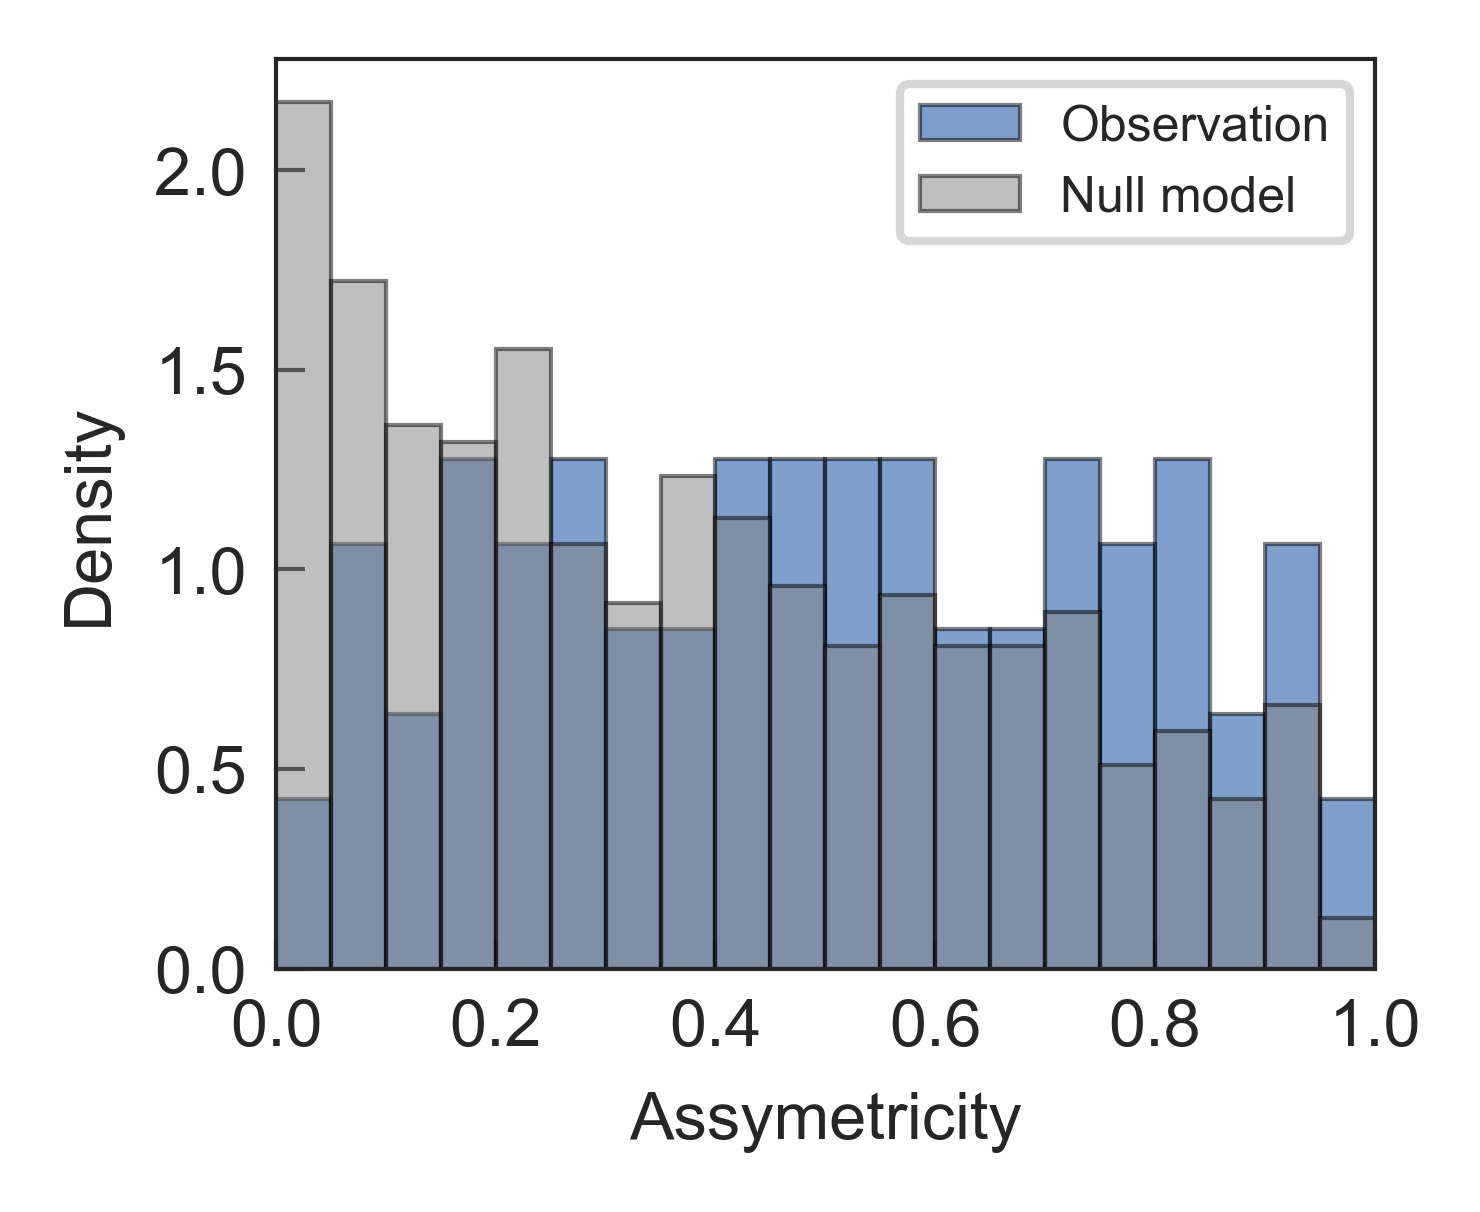

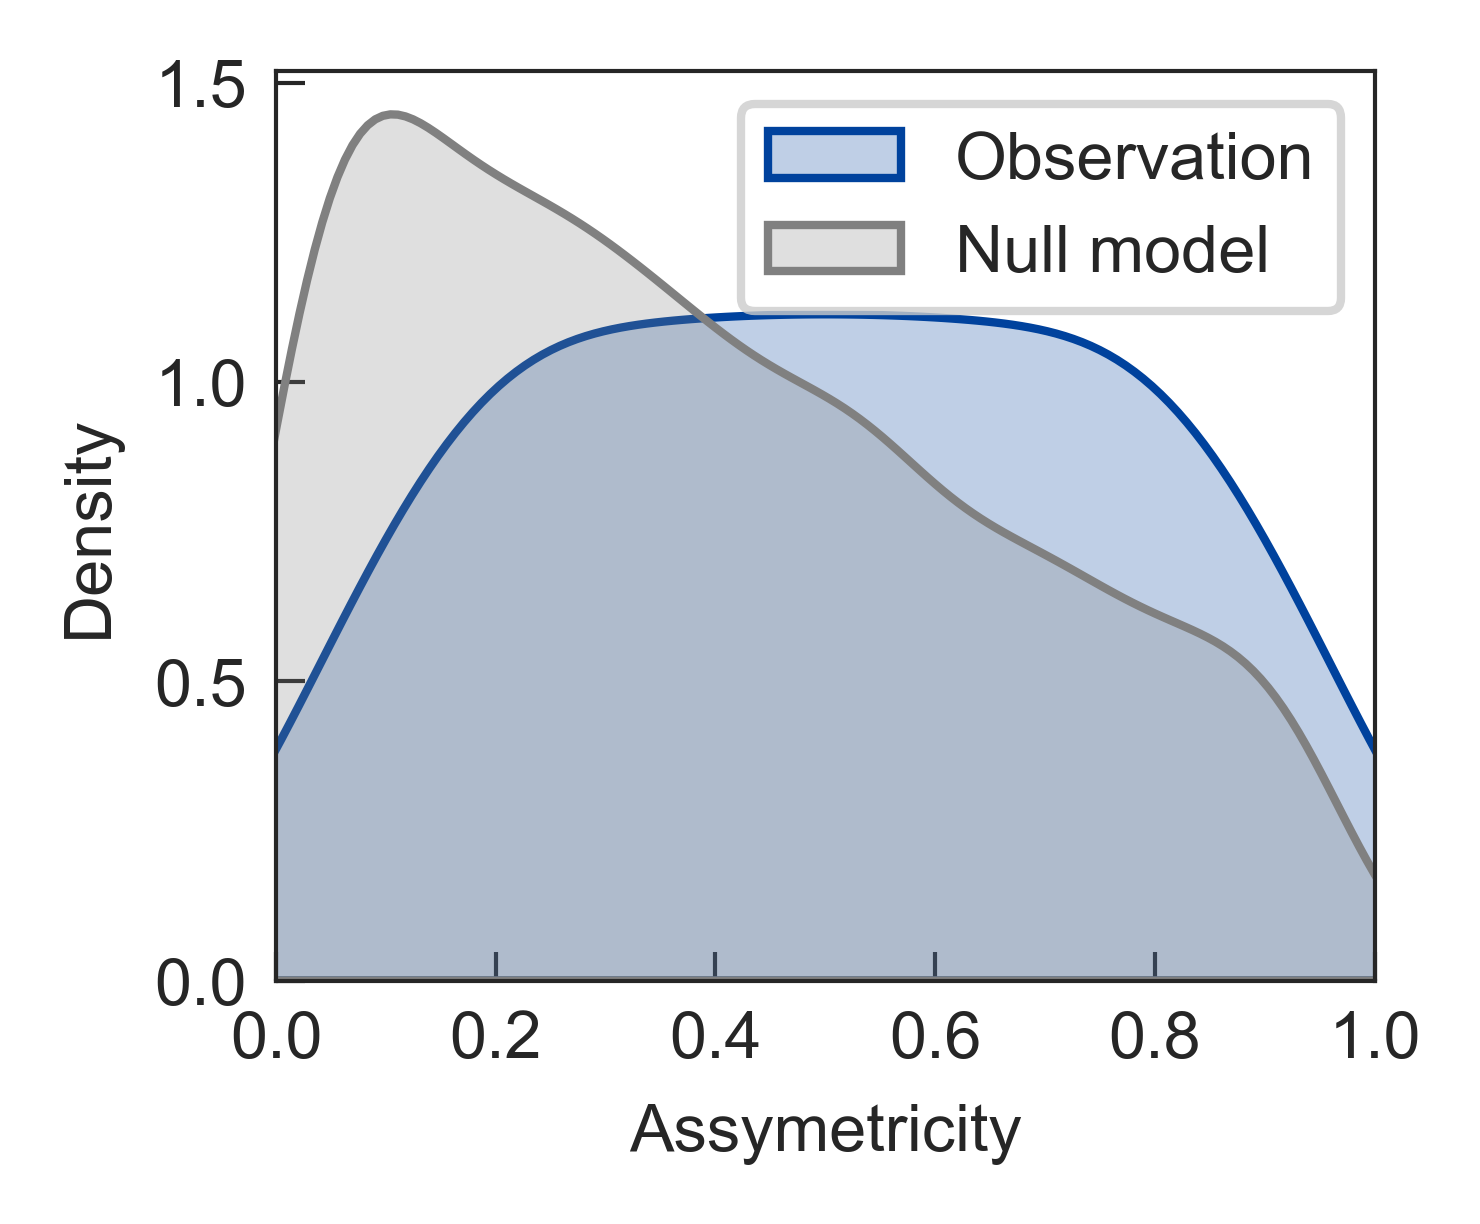

In [11]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data

f, ax = plt.subplots(1, figsize=(60*mm,50*mm), facecolor='w', edgecolor='k')
if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot='Assymetricity_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data[Variable2plot]
    data = np.concatenate((data,1-data))


    # Compute the histogram data without plotting
    hist_data, bin_edges = np.histogram(data, bins=15, density=True)

    # Plot the histogram with shaded area

    # For each data point, find which bin it belongs to and then float it slightly above that bin
    y_positions = []
    for d in data:
        #bin_idx = np.digitize(d, bin_edges) - 1
        #y_positions.append(0.5+0.14*np.random.rand())
        bin_idx = np.digitize(d, bin_edges) - 2
        y_positions.append(hist_data[bin_idx]*np.random.rand()*0.7)

    # Add some offset so that points float above the histogram bars
    y_offset = max(hist_data) * 0.02
    y_positions = [y + y_offset for y in y_positions]

    #plt.scatter(data, y_positions, marker='o', color='r', s=10, alpha=0.5, label="Data Points")
    plt.hist(data, bins=np.arange(0,1.05,0.05), density=True, alpha=0.5, color=my_cmap(0), label="Fraction", edgecolor='black', linewidth=0.5)

    #sns.kdeplot(data, shade=True,bw_adjust=.6)

if True:
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(20):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))
    #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)
    plt.hist(data_null_model, bins=np.arange(0,1.05,0.05), density=True, alpha=0.5, color='grey',label="Fraction", edgecolor='black', linewidth=0.5)
    
    
#plt.title("KDE with Floating Data Points")
plt.legend(['Observation', 'Null model'],prop={'size': 6})
plt.xlabel("Assymetricity")
plt.ylabel("Density")
plt.xlim(0, 1)

f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetricity_versionHisto.svg', bbox_inches='tight')


f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')
if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot='Assymetricity_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data[Variable2plot]
    data = np.concatenate((data,1-data))


    # Compute the histogram data without plotting
    hist_data, bin_edges = np.histogram(data, bins=15, density=True)

    # Plot the histogram with shaded area
    

    # For each data point, find which bin it belongs to and then float it slightly above that bin
    y_positions = []
    for d in data:
        #bin_idx = np.digitize(d, bin_edges) - 1
        #y_positions.append(0.5+0.14*np.random.rand())
        bin_idx = np.digitize(d, bin_edges) - 2
        y_positions.append(hist_data[bin_idx]*np.random.rand()*0.7)
    
    # Add some offset so that points float above the histogram bars
    y_offset = max(hist_data) * 0.02
    y_positions = [y + y_offset for y in y_positions]

    #plt.hist(data, bins=20, density=True, alpha=0.7, label="Fraction")
    #plt.scatter(data, y_positions, marker='o', color='r', s=10, alpha=0.5, label="Data Points")
    sns.kdeplot(data, shade=True,bw_adjust=1, color=my_cmap(0))

if True:
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(20):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))

    data_null_model = np.array(data_null_model)
    sns.kdeplot(data_null_model, shade=True,color='grey',bw_adjust=1, linewidth=1.0)
    #plt.hist(data_null_model, bins=20, density=True, alpha=0.7, label="Fraction")

#plt.title("KDE with Floating Data Points")
plt.legend(['Observation', 'Null model'])
plt.xlabel("Assymetricity")
plt.ylabel("Density")
plt.xlim(0, 1)


f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetricity_versionKDE.svg', bbox_inches='tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


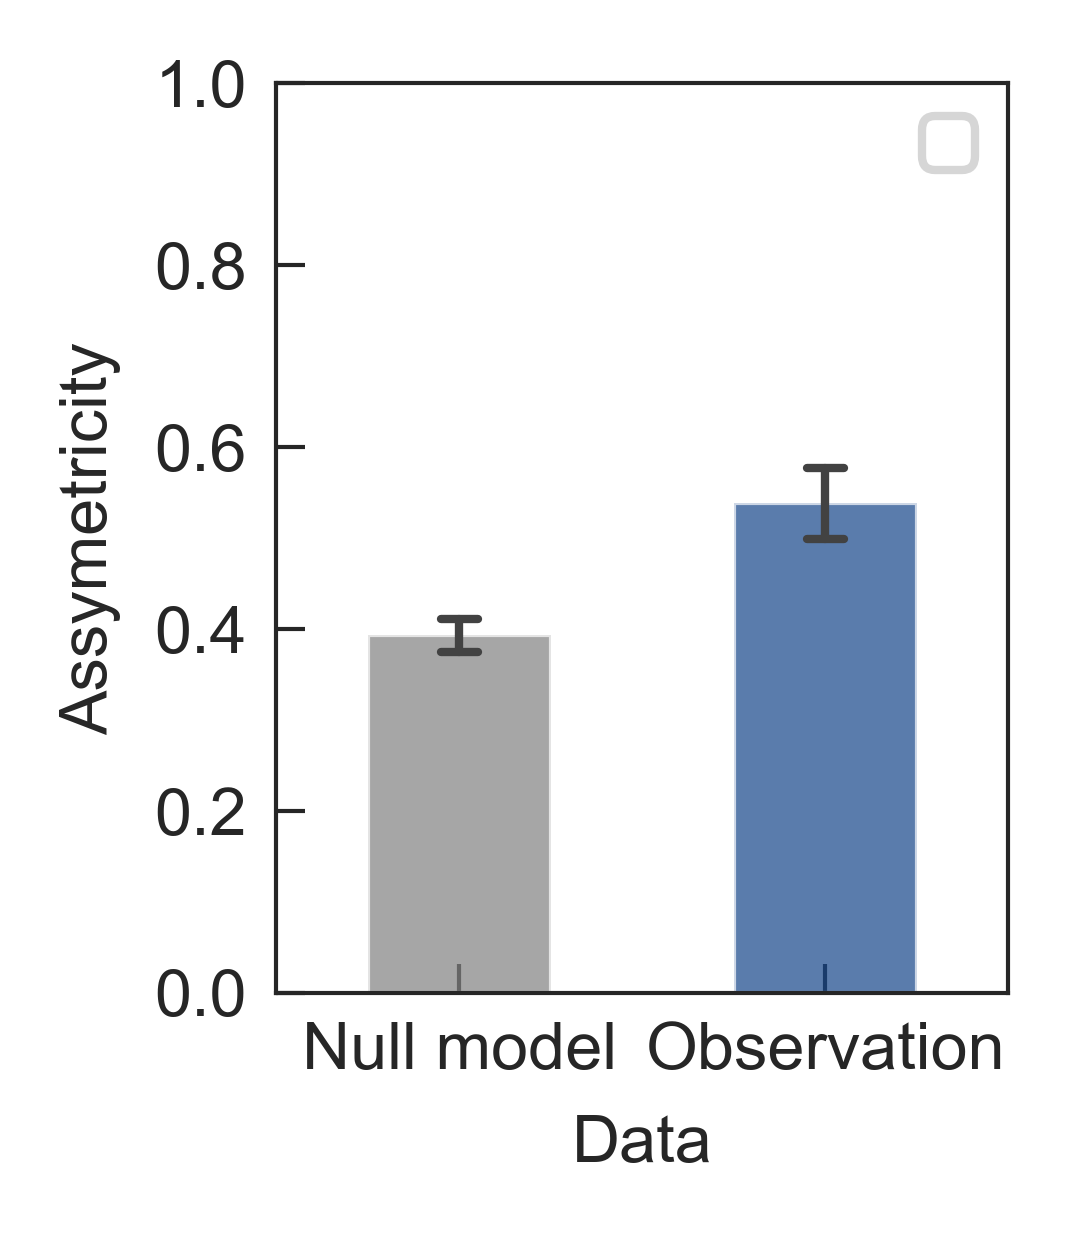

In [12]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data

if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot=Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data['Assymetricity_BC_5']



    #sns.kdeplot(data, shade=True,bw_adjust=.6)

if False:
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(50):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))
    data_null_model = np.array(data_null_model)
    #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

    data1=data_null_model
    data2=data.values

    categories = ['Null model', 'Observation']
    values = [np.mean(data1),np.mean(data2)]
    errors = [np.std(data1)/ np.sqrt(len(data1)), np.std(data2)/ np.sqrt(len(data2)) ]  # These are your error values for each category
    f, ax = plt.subplots(1, figsize=(30*mm,50*mm),facecolor='w', edgecolor='k')
    sns.barplot(x=categories, y=values,  width=0.2, linewidth=.5, palette = {"Null model": sns.color_palette()[1], "Observation": sns.color_palette()[0]})

    for i in range(len(categories)):
        plt.errorbar(
            x=i, 
            y=values[i], 
            yerr=errors[i], 
            fmt='o', 
            color='black', 
            capsize=5, 
            capthick=0.1
        )

    # Convert the data into a DataFrame
    #sns.boxplot(x='Data', y='Value', data=df, order=['Null model', 'Observation'], width=0.2, boxprops=dict(alpha=.7),  linewidth=.5, palette = {"Null model": sns.color_palette()[1], "Observation": sns.color_palette()[0]})
    plt.ylabel('Assymetricity')
    plt.legend()
    plt.show()

    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot.svg',bbox_inches='tight')


if True:
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(5):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))
    data_null_model = np.array(data_null_model)
    #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

   
    data1=data_null_model
    data2=data.values

    combined_data = np.concatenate([data1, data2])
    labels = ['Null model'] * len(data1) + ['Observation'] * len(data2)
    df = pd.DataFrame({'Value': combined_data, 'Data': labels})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.legend()
    plt.show()

    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot.svg',bbox_inches='tight')


In [13]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

from scipy.stats import ttest_ind

# Perform the t-test
x=abs(data)
y=abs(data_null_model)
t_stat, p_value = ttest_ind(x,y,equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.100f}")

T-statistic: 3.3877
P-value: 0.0011781504081072949070146949068771391466725617647171020507812500000000000000000000000000000000000000


In [22]:
np.mean(x), np.sqrt(np.var(x)/len(x))

(0.5377623581280815, 0.038351277312976516)

In [15]:
np.std(data2)

0.2629231107419637

In [16]:
np.sqrt(np.var(data2)/len(data2))

0.03835127731297652

In [17]:
np.sqrt(np.var(data2)/len(data2))

0.03835127731297652

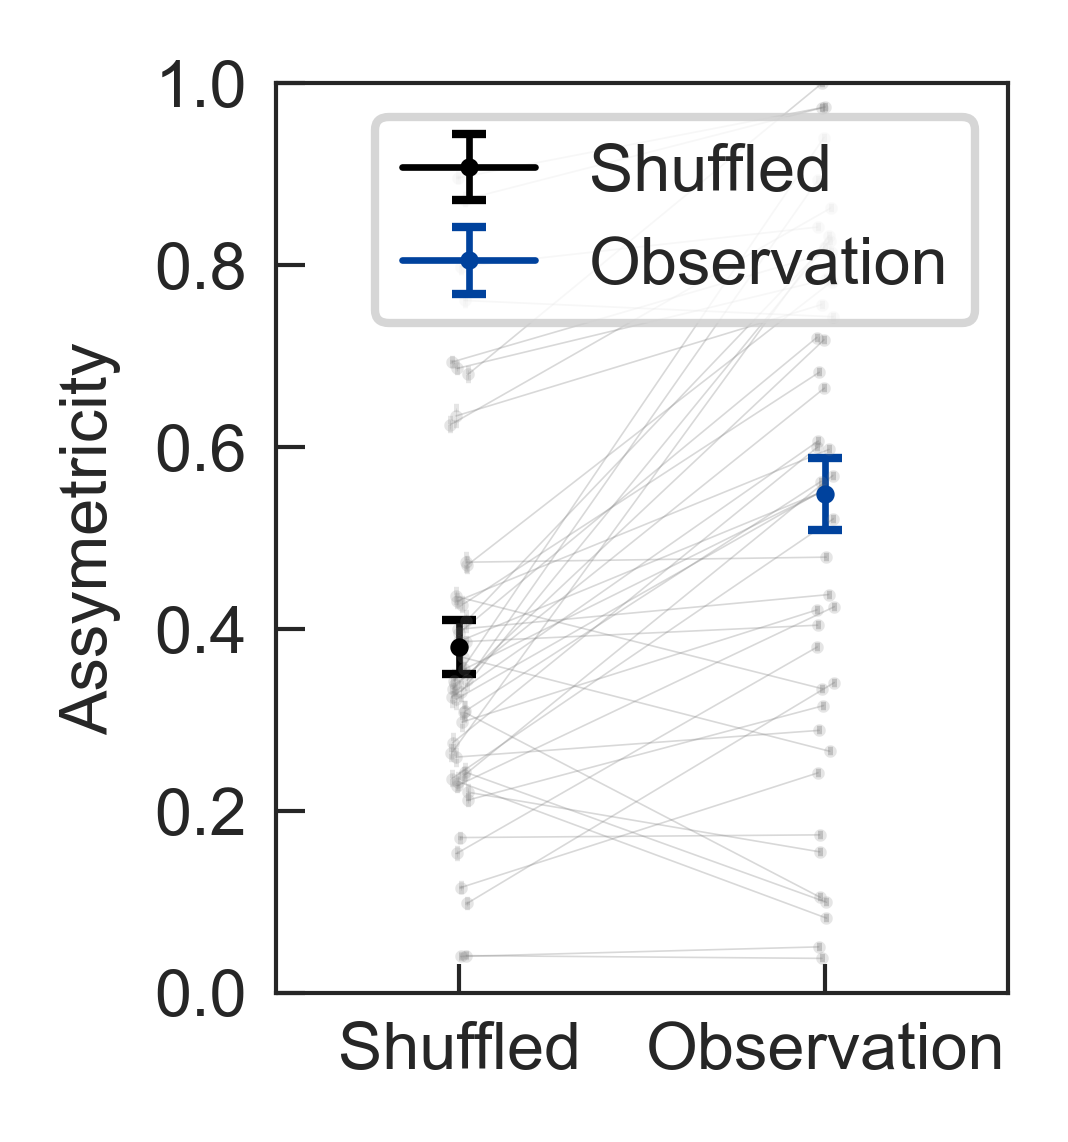

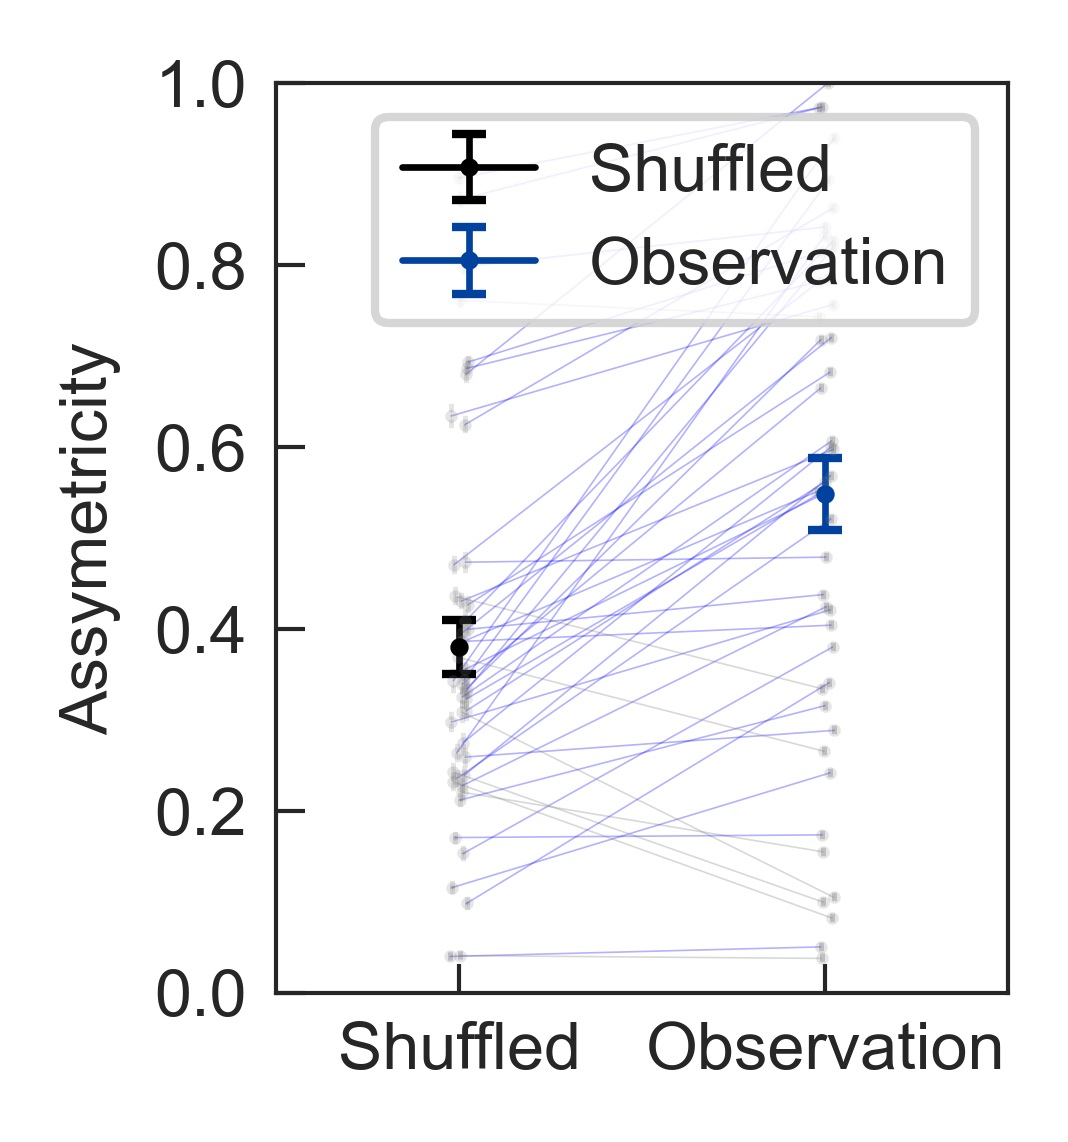

In [18]:
########################################################
########################################################
# Fig 1-5-2
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']

# Plotting real data

Null_model_rep=1000

if True:
    Variable2plot_list=['ASVs_notinsub1_3',
           'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
            'Additivity3_5', 'Assymetricity_BC_5',
           'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
           'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
           'ASVs_overlap1_5', 'ASVs_overlap2_5']


    type_name='MN_12'
    Variable2plot=Variable2plot='SimilarityTo1_BC_5'

    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data =  data['Assymetricity_BC_3']



    #sns.kdeplot(data, shade=True,bw_adjust=.6)


if True:
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        for _ in range(Null_model_rep):
            c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
            c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
            c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
            c_1=c_1*(c_1>1e-4)
            c_2=c_2*(c_2>1e-4)
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

            F1=np.sum(np.minimum(moc_c1,c_mix))
            F2=np.sum(np.minimum(moc_c2,c_mix))

            similarity=(F1)/(F1+F2)
            data_null_model.append(abs(2*similarity-1))
    
    data_null_model = np.array(data_null_model)
    data_null_model = data_null_model.reshape([-1,Null_model_rep])
    #sns.kdeplot(data_null_model, shade=True,bw_adjust=1)

    
    data1=data_null_model
    data2=data.values

    #combined_data = np.concatenate([data1, data2])
    #labels = ['Null model'] * len(data1) + ['Observation'] * len(data2)
    #df = pd.DataFrame({'Value': combined_data, 'Data': labels})
    
    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        plt.plot(plot_x,plot_y, linewidth=0.2, color='grey',alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot_style1.svg',bbox_inches='tight')
    
    f, ax = plt.subplots(1, figsize=(40*mm,50*mm),facecolor='w', edgecolor='k')
    
    ##Version2
    for i in range(data1.shape[0]):
        plot_x=[0,1]+(np.random.rand(2)-0.5)*0.05
        plot_y=[np.mean(data1[i,:]),data2[i]]
        sem = [np.std(data1[i,:])/np.sqrt(Null_model_rep),0]
        plt.errorbar(plot_x, plot_y, yerr=sem, fmt='o', color="grey", markersize=0.5,  elinewidth=0.1,alpha=0.2,  capsize=0.3)
        #plt.scatter(plot_x, plot_y, color="grey", s=0.5, alpha=0.5)
        colors=['grey','red','blue']
        
        colorcoding=0
        if plot_y[0]<plot_y[1]:
            colorcoding=2
        plt.plot(plot_x,plot_y, linewidth=0.2, color=colors[colorcoding],alpha=0.3)
    #sns.barplot(x='Data', y='Value', data=df, errorbar=('se'), order=['Null model', 'Observation'], width=0.5,  linewidth=.5, capsize=.1, errwidth=1, alpha=0.7, palette = {"Null model": "grey", "Observation": my_cmap(0)})
    
    mean_x=[0,1]
    mean_y=[np.mean(data1), np.mean(data2)]
    sem=[np.sqrt(np.var(np.mean(data1,1))/len(np.mean(data1,1))),np.sqrt(np.var(data2)/len(data2))]
    colors=['black', my_cmap(0)]
    labels=['Shuffled','Observation']
    for i in range(2):   
        plt.errorbar(mean_x[i], mean_y[i], yerr=sem[i], marker='o', linestyle='-', markersize=1.2, linewidth=.8, color=colors[i],capsize=2.0, label=labels[i])
    

    # Set plot limits and labels
    plt.xlim(-.5, 1.5)
    plt.ylim(0, 1)
    plt.ylabel('Assymetricity')
    plt.xticks([0,1], ['Shuffled', 'Observation'])
    plt.legend()
    f.savefig(FigureTitle + '/Fig_1-5_DistributionOfAssymetiricty_boxplot_style2.svg',bbox_inches='tight')

    


0.48936170212765956
0.851063829787234


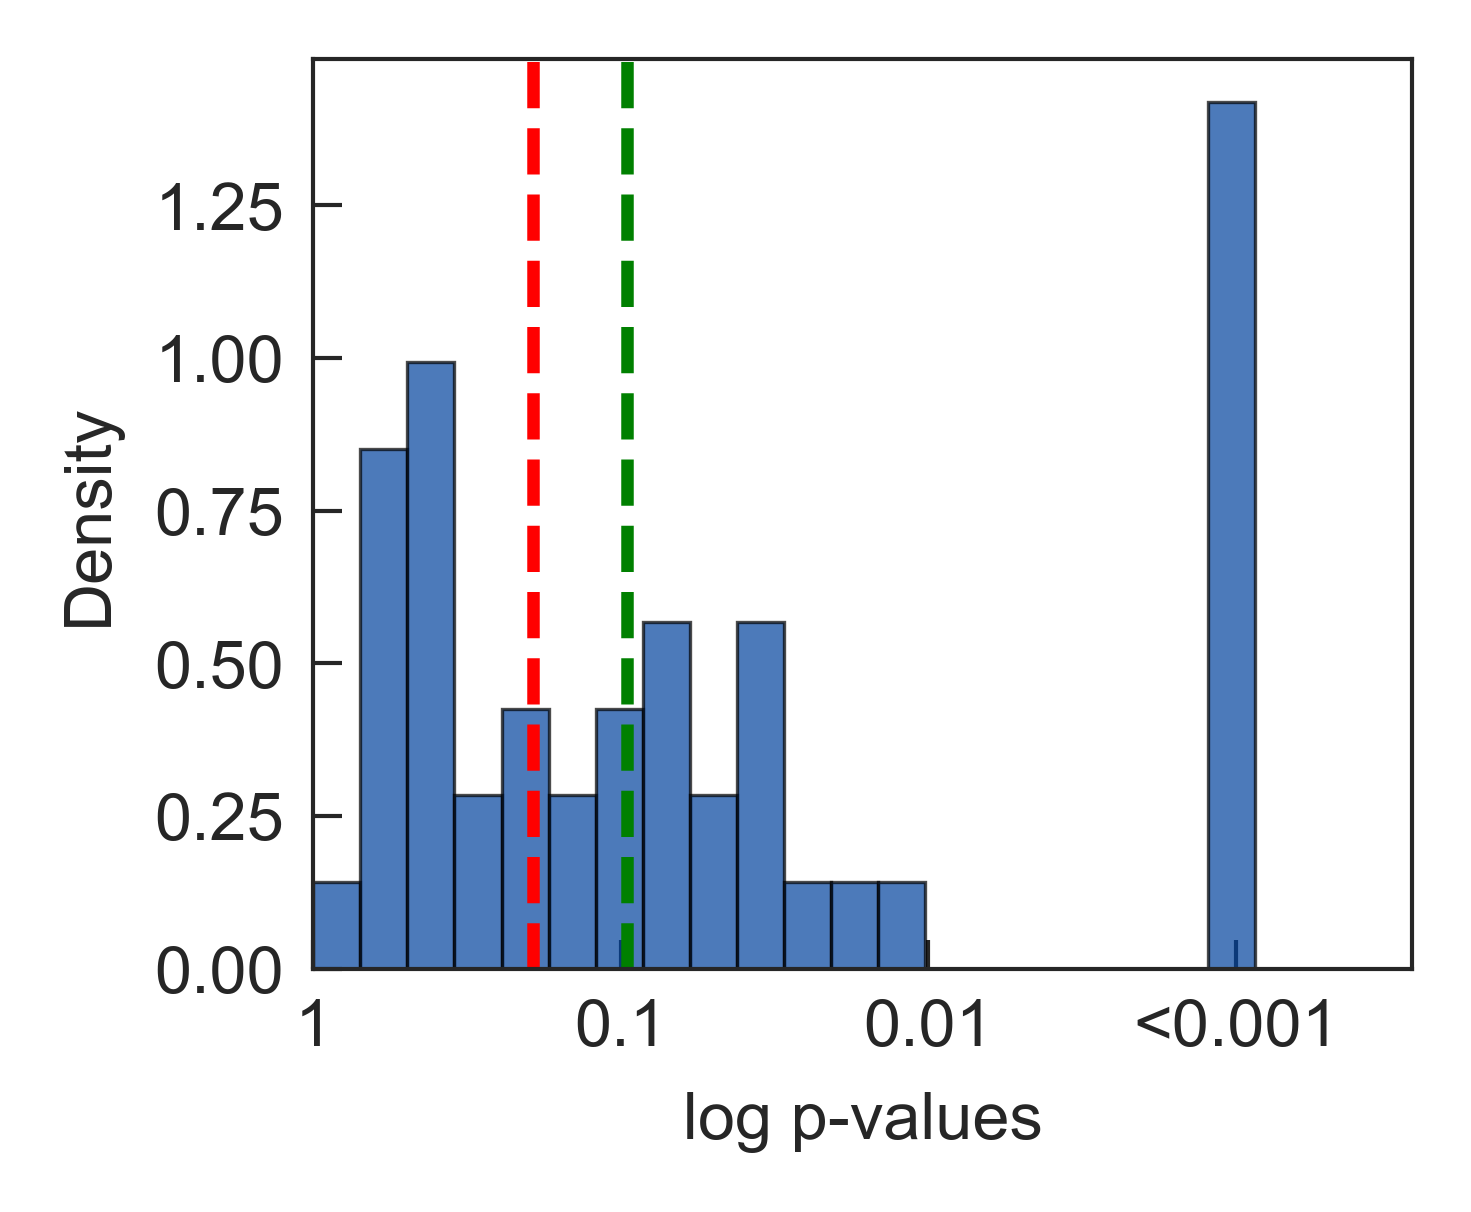

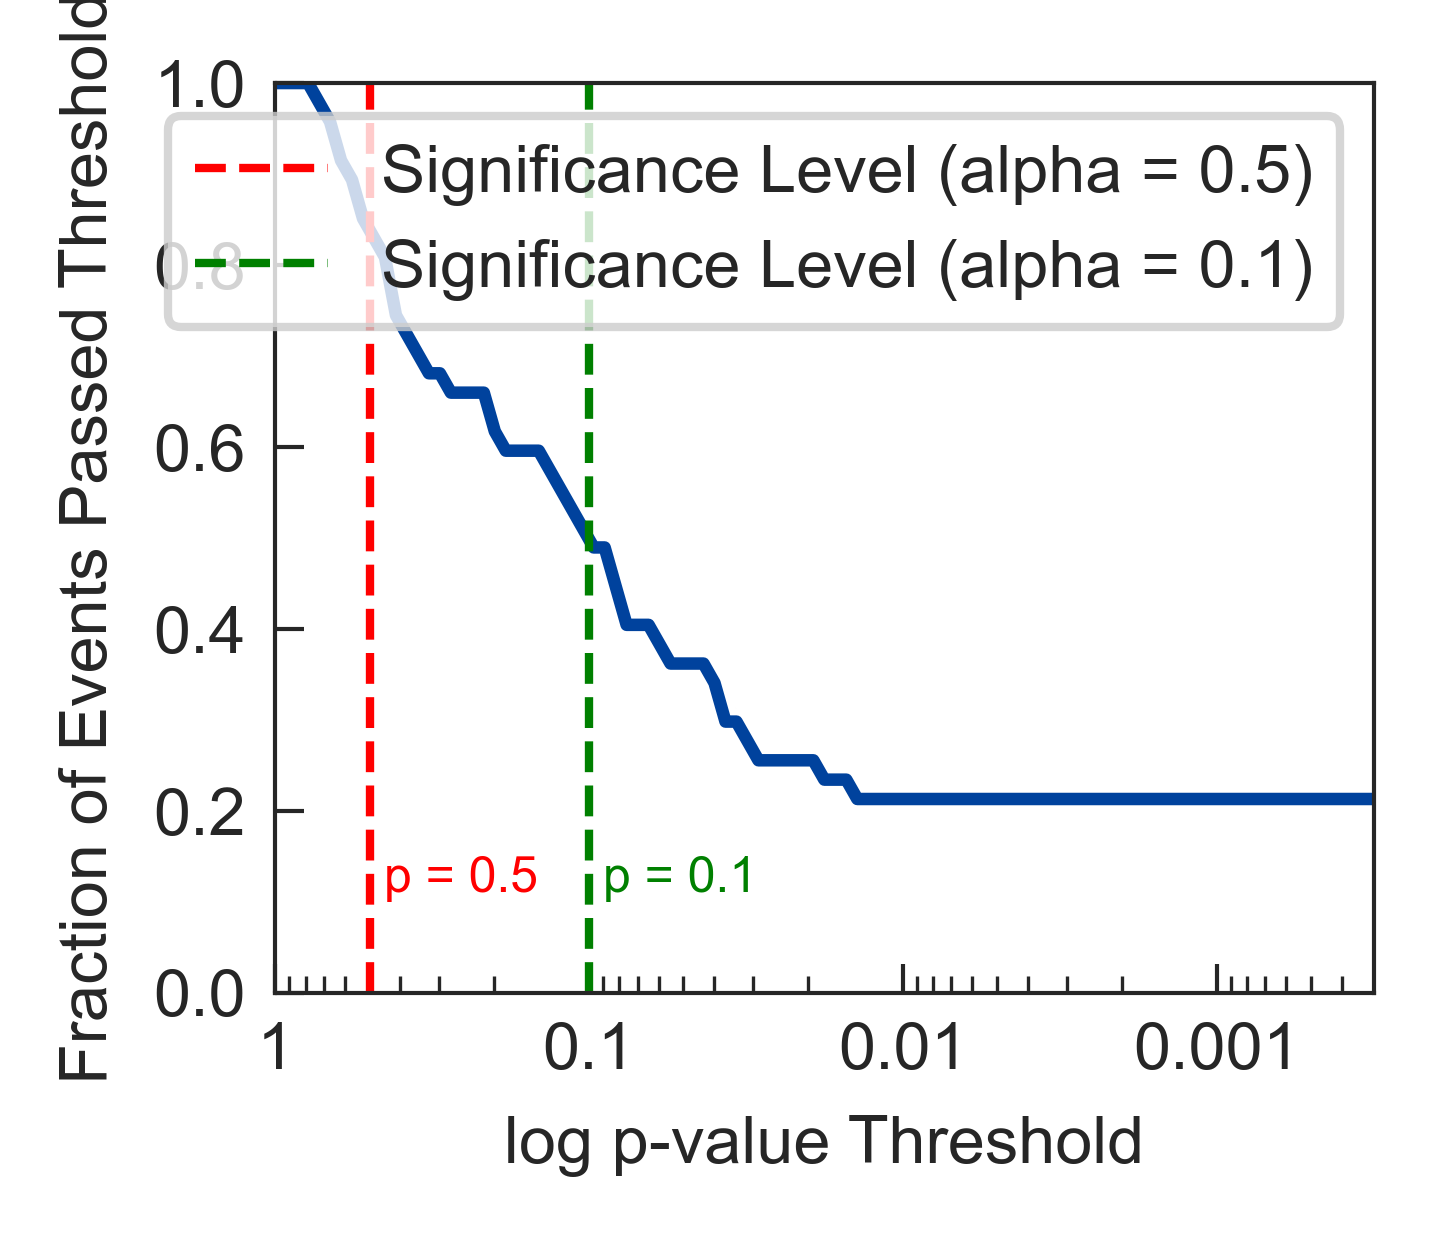

In [19]:
from scipy.stats import norm
p_list=[]
p_list2=[]
for i in range(data1.shape[0]):
    obs=data2[i]
    null_y=data1[i,:]
    # Single sample data point
    sample_data = obs

    # Null hypothesis mean (B) and null hypothesis variance
    null_mean = 0
    null_variance = np.sum(null_y**2-0)/len(null_y) # Replace with your actual null variance
    
    # Calculate the Z-score
    z_score = (sample_data - null_mean) / np.sqrt(null_variance)

    # Calculate the two-tailed p-value
    p_value = (1 - norm.cdf(np.abs(z_score)))

    p_list.append(p_value)
    p_list2.append(np.mean(null_y>obs))

    
    
    
    
f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')
p_list2=np.array(p_list2)


range_n=3
bin_edges = np.linspace(start=0, stop=range_n, num=21)  # Adjust as needed

plt.hist(-np.log10(p_list2+10**(-range_n)),bins=bin_edges,color=my_cmap(0), alpha=0.7, linewidth=0.4, edgecolor='black', density=True)
plt.gca().invert_xaxis()

plt.axvline(-np.log10(0.2), color='red', linestyle='--', label='p=0.05')
plt.axvline(-np.log10(0.1), color='green', linestyle='--', label='p=0.1')

plt.xlim(0, range_n+0.5)

# Set x-axis tick labels as 10^(-n)
plt.gca().xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.gca().set_xticks([n*0.98 for n in range(range_n+1)])  # Tick positions
plt.gca().set_xticklabels(['1', '0.1', '0.01']+['<0.001'])  # Tick labels
#plt.grid()

plt.xlabel('log p-values')
plt.ylabel('Density')
f.savefig(FigureTitle + '/Fig_1-5_DistributionOfPval_histogram.svg',bbox_inches='tight')

print(np.mean(p_list2<0.1))
print(np.mean(p_list2<0.5))



f, ax = plt.subplots(1, figsize=(60*mm,50*mm),facecolor='w', edgecolor='k')
# Sample p-values (replace with your actual p-values)
p_values = p_list2

# Create an array of logarithmically spaced p-value thresholds
thresholds = np.logspace(-3.5, 0, 101)  # Adjust the range and number of thresholds as needed

# Calculate the fraction of samples passing each threshold
pass_fraction = [np.mean(np.array(p_values) <= threshold) for threshold in thresholds]

# Create a plot with logarithmic scales
plt.semilogx(thresholds, pass_fraction, linestyle='-', color=my_cmap(0))

# Highlight the significance level (e.g., alpha = 0.05)
alpha = 0.5
plt.axvline(alpha, linestyle='--', linewidth=1, color='red', label=f'Significance Level (alpha = {alpha})')
plt.text(alpha*0.90, 0.1, f'p = {alpha}', fontsize=6, color='red', verticalalignment='bottom')

alpha = 0.1

plt.axvline(alpha, linestyle='--', linewidth=1, color='green', label=f'Significance Level (alpha = {alpha})')
plt.text(alpha*0.90, 0.1, f'p = {alpha}', fontsize=6, color='green', verticalalignment='bottom')

plt.ylim(0,1)
plt.xlim(10**(-range_n-0.5),10**0, )
plt.gca().invert_xaxis()

# Set plot labels and legend
plt.xlabel('log p-value Threshold')
plt.ylabel('Fraction of Events Passed Threshold')
plt.legend()
f.savefig(FigureTitle + '/Fig_1-5_DistributionOfPval_accumulated.svg',bbox_inches='tight')

plt.gca().set_xticks([1, 0.1, 0.01, 0.001])  # Tick positions
plt.gca().set_xticklabels(['1', '0.1', '0.01']+['0.001'])  # Tick labels

# Show the plot
plt.show()

    

In [20]:
np.mean(np.array(p_list)<0.05) , np.mean(np.array(p_list2)<0.05)


(0.2553191489361702, 0.3617021276595745)